# Livrable 3 - Bloc IA

Groupe 2 :
- Hugo Joseph
- Matthieu Marconnet Regidor
- Thomas Hallliez
- Jaad Chokr Nagib

## Introduction

L'entreprise pharmaceuthique indienne HumanForYou souffre d'un trop fort taux de rotation, ce qui nuit à ses activités.  
Afin d'y remédier, une collaboration avec notre équipe a été décidée.  

La tâche qui nous a été confié est un projet visant à développer une IA capable d'analyser les données fournis par les ressources humaines de l'entreprise, et d'en déduire les facteurs poussant les employés à démissioner. 

Cela permettra d'identifier les points à améliorer au sein de l'entreprise et de régler le problème de rotation excessive. 

Les livrables précédents ont préalablement servis à analyser l'aspect ethique de ce projet, puis de fournir une base de documents nous permettant de le mener à bien.

Dans ce livrable, nous allons programmer l'algorithme répondant aux besoins du projet. Le code sera présenté dans ce fichier notebook.

In [869]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## Création du modèle de prédiction

### Traitement des données

Le traitement de données que nous avons appliquer constiste en plusieurs étapes :
1. Enlever les données non utiles et/ou intrusive pour la vie privé. Par exemple des données étant constante dans le data set (ex : Over18) ne servent aucun intêret.
2. Transformer certaines données. Par exemple Attrition que nous passons de "Yes" ou "No" à 1 ou 0 pour faciliter la compréhension du modèle.
3. Encoder les données catégorielles avec un one hot encoder.
4. Scaler les données numériques.
5. Concaténer les données en un seul dataframe.
6. Le traîtement des données manquantes se fait automatiquement durant l'encodage des données catégorielles et le scaling des données numériques.

In [870]:
general_data = pd.read_csv('assets/general_data.csv')

general_data['Attrition'] = general_data['Attrition'].map({'Yes': 1, 'No': 0})
general_data.drop(['EmployeeCount'], axis=1, inplace=True)
general_data.drop(['StandardHours'], axis=1, inplace=True)
general_data.drop(['Over18'], axis=1, inplace=True)
general_data.drop(['EmployeeID'], axis=1, inplace=True)
general_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,0,Travel_Rarely,Sales,6,2,Life Sciences,Female,1,Healthcare Representative,Married,131160,1.0,11,0,1.0,6,1,0,0
1,31,1,Travel_Frequently,Research & Development,10,1,Life Sciences,Female,1,Research Scientist,Single,41890,0.0,23,1,6.0,3,5,1,4
2,32,0,Travel_Frequently,Research & Development,17,4,Other,Male,4,Sales Executive,Married,193280,1.0,15,3,5.0,2,5,0,3
3,38,0,Non-Travel,Research & Development,2,5,Life Sciences,Male,3,Human Resources,Married,83210,3.0,11,3,13.0,5,8,7,5
4,32,0,Travel_Rarely,Research & Development,10,1,Medical,Male,1,Sales Executive,Single,23420,4.0,12,2,9.0,2,6,0,4


In [871]:
manager_survey_data = pd.read_csv('assets/manager_survey_data.csv')

manager_survey_data.drop(['EmployeeID'], axis=1, inplace=True)

manager_survey_data.head()

,JobInvolvement,PerformanceRating
0,3,3
1,2,4
2,3,3
3,2,3
4,3,3


In [872]:
employee_survey_data = pd.read_csv('assets/employee_survey_data.csv')

employee_survey_data.drop(['EmployeeID'], axis=1, inplace=True)

employee_survey_data.head()

,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,3.0,4.0,2.0
1,3.0,2.0,4.0
2,2.0,2.0,1.0
3,4.0,4.0,3.0
4,4.0,1.0,3.0


In [873]:
in_time = pd.read_csv('assets/in_time.csv')
out_time = pd.read_csv('assets/out_time.csv')

in_time.drop('Unnamed: 0', axis=1, inplace=True)
out_time.drop('Unnamed: 0', axis=1, inplace=True)

for d in in_time:
    in_time[d] = pd.to_datetime(in_time[d])
    
for d in out_time:
    out_time[d] = pd.to_datetime(out_time[d])
    
in_time.head()

,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,NaT,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,NaT,...,NaT,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaT,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,NaT,2015-01-02 10:15:44,2015-01-05 10:21:05,NaT,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,NaT,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaT,NaT,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,NaT,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,NaT,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaT,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,NaT,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,NaT,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaT,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,NaT,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,NaT,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaT,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09


In [874]:
average_hours_per_employee = []


for in_row, out_row in zip(in_time.iterrows(), out_time.iterrows()):

    # Calculer la moyenne des heures travaillées pour chaque jour
    daily_hours = (out_row[1] - in_row[1]).dt.total_seconds() / 3600
    average_hours = daily_hours.mean(skipna=True)
    average_hours_per_employee.append(average_hours)

time_data = pd.DataFrame({
    'AverageHours': average_hours_per_employee
    
})

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
    
time_data_scaled = pd.DataFrame(scaler.fit_transform(time_data), columns=time_data.columns)

time_data_scaled.head()

,AverageHours
0,-0.244123
1,0.013564
2,-0.513073
3,-0.378424
4,0.227886


In [875]:
import matplotlib.pyplot as plt

def missing_values(data):
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    
    data_num = data.select_dtypes(include=[np.number])
    data_cat = data.select_dtypes(include=[object])
    
    if data.isnull().sum().sum() > 0:
        imputer.fit(data_num)
        data_num_imputed = pd.DataFrame(imputer.transform(data_num), columns=data_num.columns)
        
        if data_cat.empty == False:
            data_cat_encoded = pd.get_dummies(data_cat)
        
        data_num_scaled = pd.DataFrame(scaler.fit_transform(data_num_imputed), columns=data_num_imputed.columns)
        
        if data_cat.empty == False:
            return data_num_scaled, data_cat_encoded
        else:
            return data_num_scaled, data_cat
    
    else :
        return data_num, data_cat

general_data_num_scaled, general_data_cat_encoded = missing_values(general_data)
manager_survey_data_num_scaled, manager_survey_data_cat_encoded = missing_values(manager_survey_data)
employee_survey_data_num_scaled, employee_survey_data_cat_encoded = missing_values(employee_survey_data)
        
data_prepared = pd.concat([general_data_num_scaled, time_data_scaled, general_data_cat_encoded, manager_survey_data_num_scaled, manager_survey_data_cat_encoded, employee_survey_data_num_scaled, employee_survey_data_cat_encoded], axis=1)
data_prepared["Attrition"] = general_data["Attrition"]

data_num_prepared = data_prepared.select_dtypes(include=[np.number])
data_cat_prepared = data_prepared.select_dtypes(include=[object])

data_prepared.head()

,Age,Attrition,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1.541369,0,-0.393938,-0.891688,-0.961486,1.405136,-0.678464,-1.150554,-0.932014,-1.322079,...,False,False,False,True,False,3,3,0.252200,1.156302,-1.085336
1,-0.648668,1,0.099639,-1.868426,-0.961486,-0.491661,-1.079486,2.129306,0.241988,-0.678877,...,False,False,False,False,True,2,4,0.252200,-0.663899,1.757749
2,-0.539166,0,0.963398,1.061787,1.749610,2.725053,-0.678464,-0.057267,2.589994,-0.807517,...,True,False,False,True,False,3,3,-0.665460,-0.663899,-2.506879
3,0.117845,0,-0.887515,2.038524,0.845911,0.386301,0.123580,-1.150554,2.589994,0.221606,...,False,False,False,True,False,2,3,1.169861,1.156302,0.336206
4,-0.539166,0,0.099639,-1.868426,-0.961486,-0.884109,0.524602,-0.877232,1.415991,-0.292956,...,True,False,False,False,True,3,3,1.169861,-1.573999,0.336206


### Schémas

Cette partie se compose de différentes figures servant à analyser visuellement les tendances et les corrélations entre différentes colonnes.

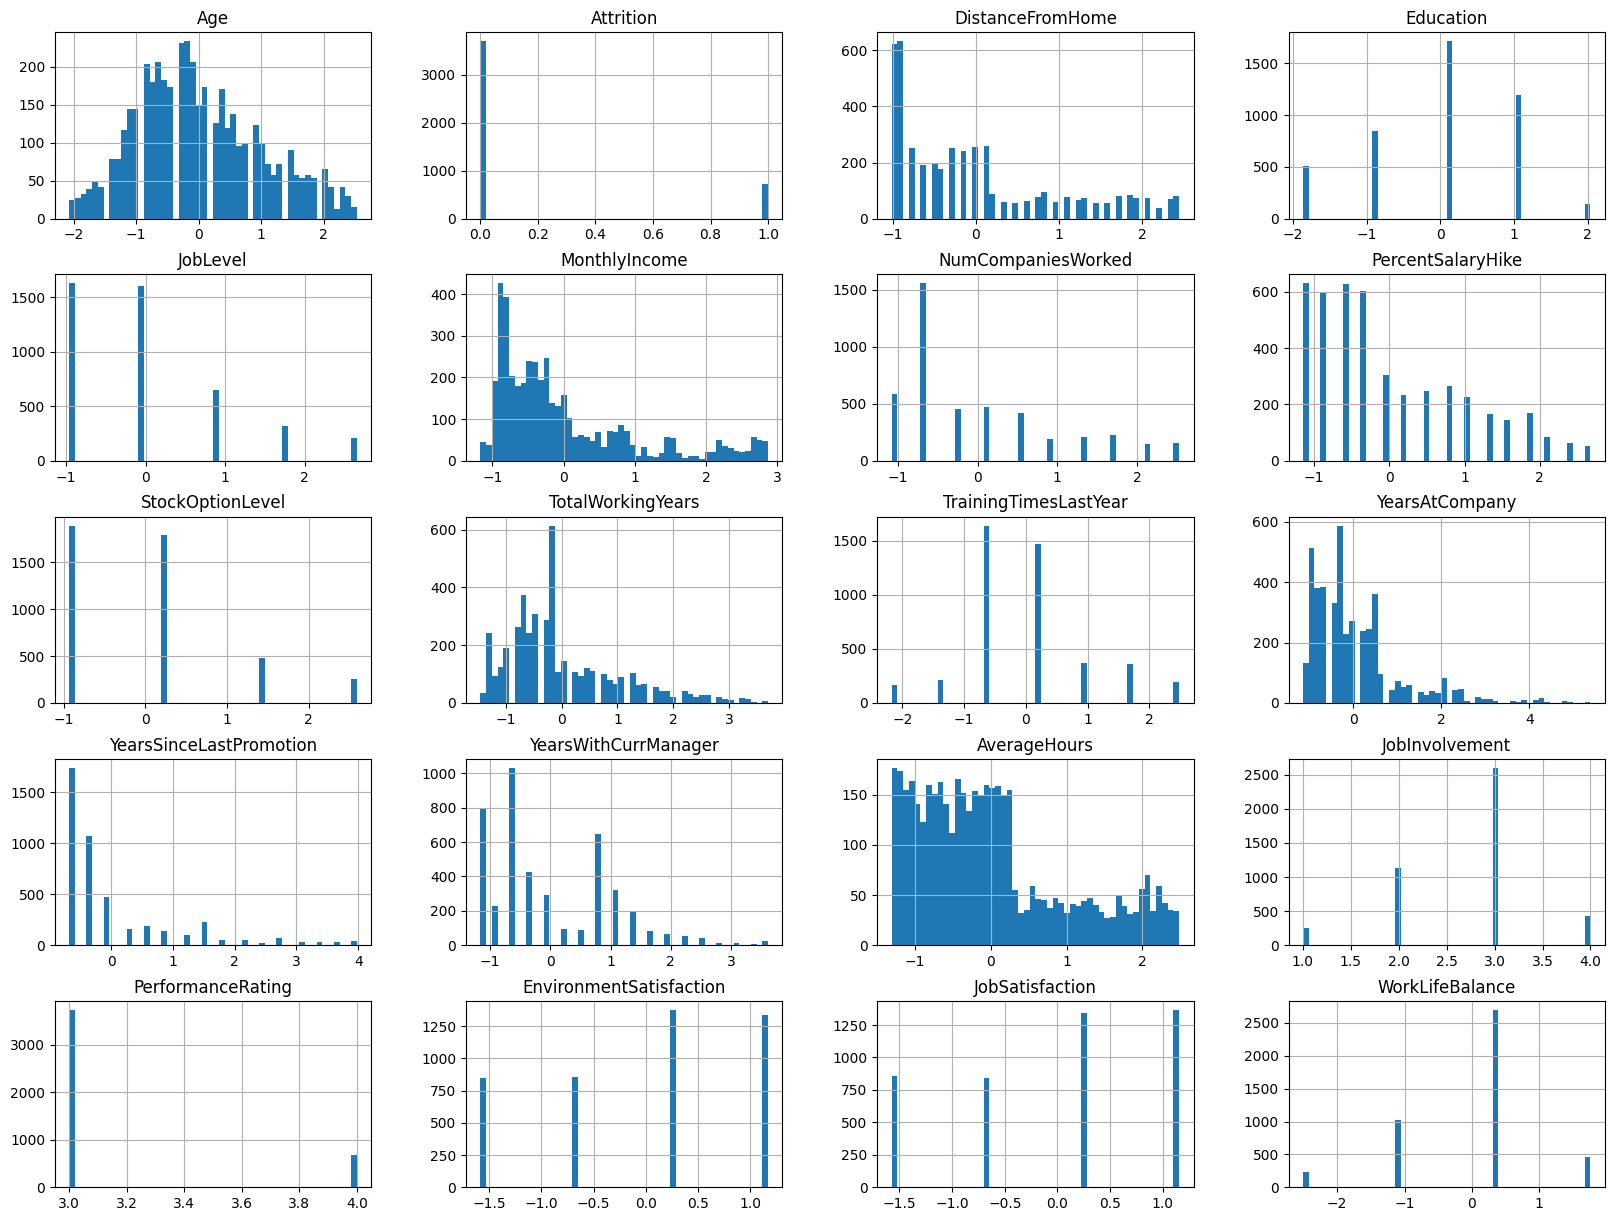

In [876]:
import matplotlib.pyplot as plt
import seaborn as sns

data_num_prepared.hist(bins=50, figsize=(20, 15))
plt.show()

Ces graphes représentent la répartition respective des valeurs des différentes données.  
Elles sont déjà mise à l'échelle, et permettent donc de visualiser graphiquement la répartition aproximative des valeurs.  

On peut par exemple observer qu'il y a plus d'employés ayant un revenue bas que d'employés ayant un revenu haut. 
On observe aussi des valeurs qui ont l'air d'être corrélées (cela reste à confirmer par la suite), comme "EnvironmentSatisfaction" et "JobSatisfaction".

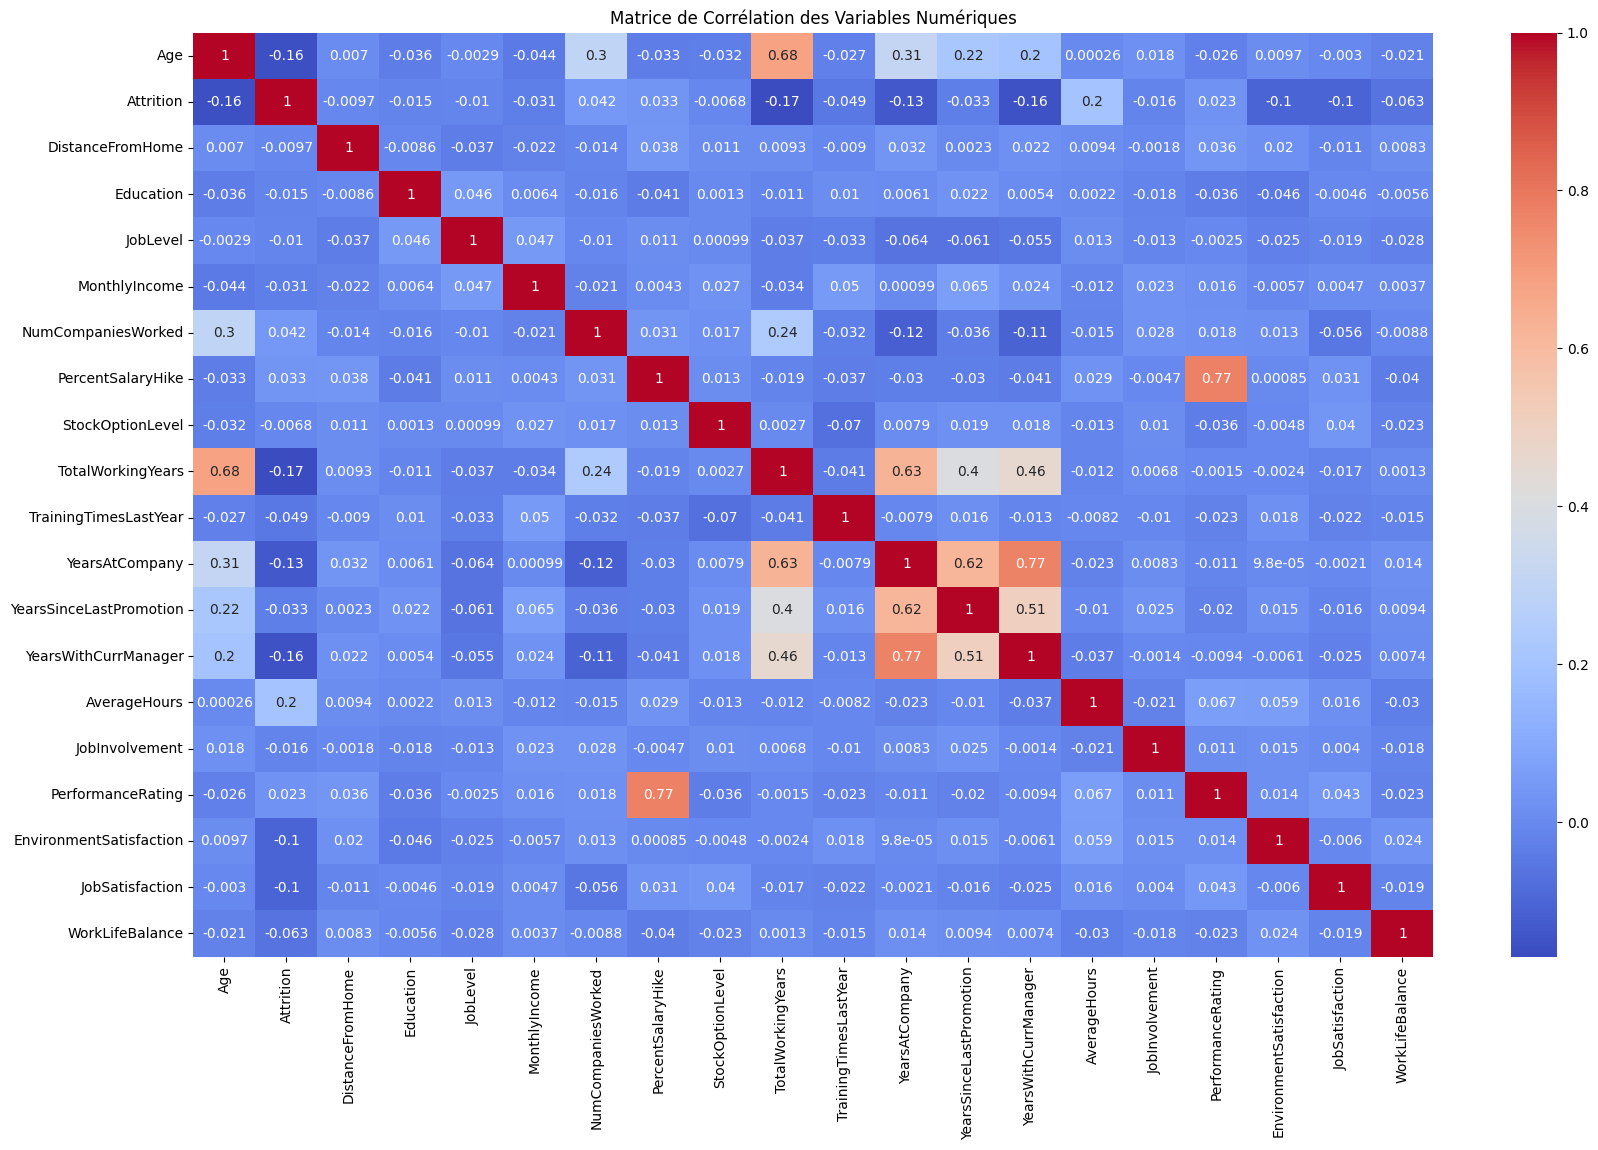

In [877]:
corr_matrix = data_num_prepared.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()

La Matrice de corrélation ci-dessus nous permet d'identifier les valeurs numériques étant plus ou moins corrélées.  

Une valeur approchant 1 signifie que l'augmentation d'une implique l'augmentation de l'autre.  
Une valeur proche de -1 signifie que l'augmentation d'une implique la diminution de l'autre.  
Et une valeur proche de zéro indique une corrélation faible voir non existante entre les 2.  

Les plus corrélées, avec 0,77, sont "PercentSalaryHike" et "PerformanceRating", ce qui pourrait s'expliquer par le fait que les augmentations sont souvent faites en conséquence des évaluation des managers.  

En regardant les corrélation avec l'Attrition nous remarquons par exemple l'Age (à -0.16) et les heures moyennes (à 0.2).  

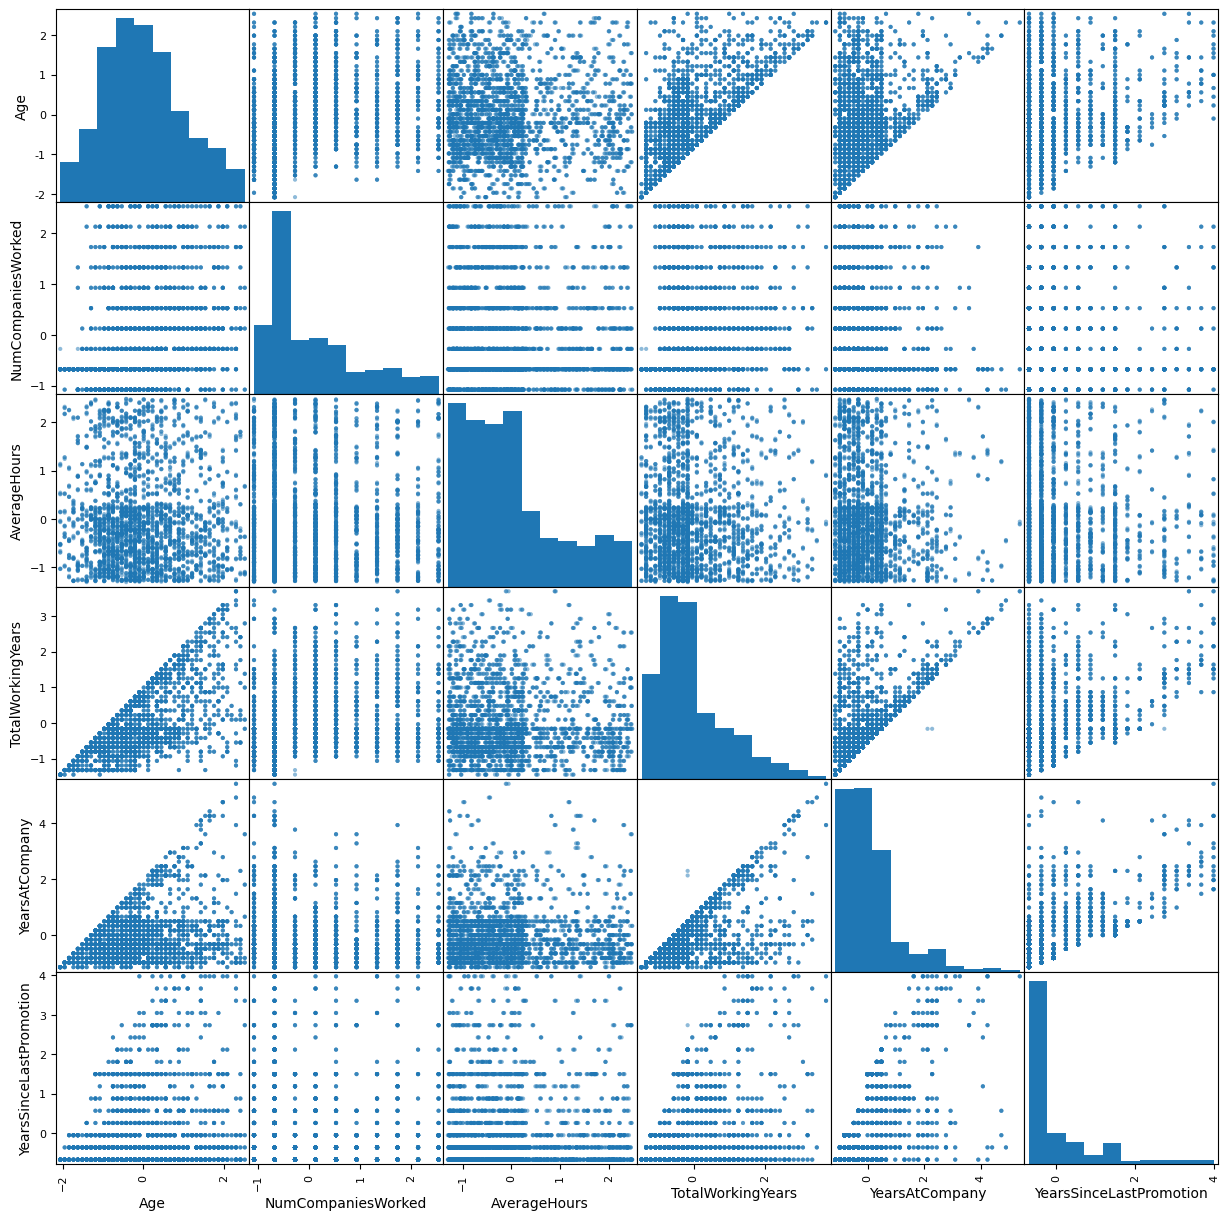

In [878]:
attributes = ["Age", "NumCompaniesWorked","AverageHours", "TotalWorkingYears", "YearsAtCompany", "YearsSinceLastPromotion"]
scatter_matrix = pd.plotting.scatter_matrix(data_prepared[attributes], figsize=(15, 15))
plt.show()

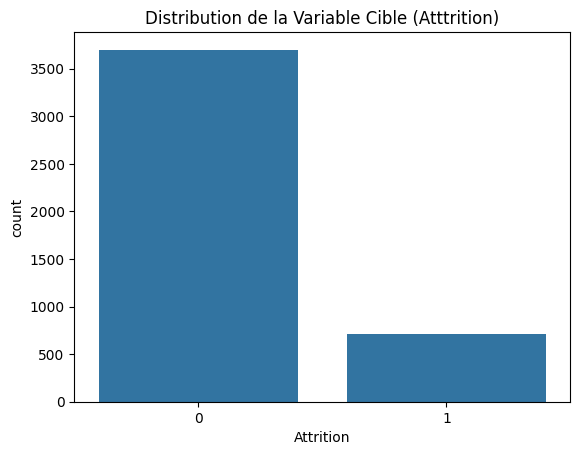

In [879]:
sns.countplot(x='Attrition', data=data_prepared)
plt.title('Distribution de la Variable Cible (Atttrition)')
plt.show()

L'Attrition est fortement inégale. Ce qui correspond à peu près au taux de rotation à 15% anoncé par HumanForYou.

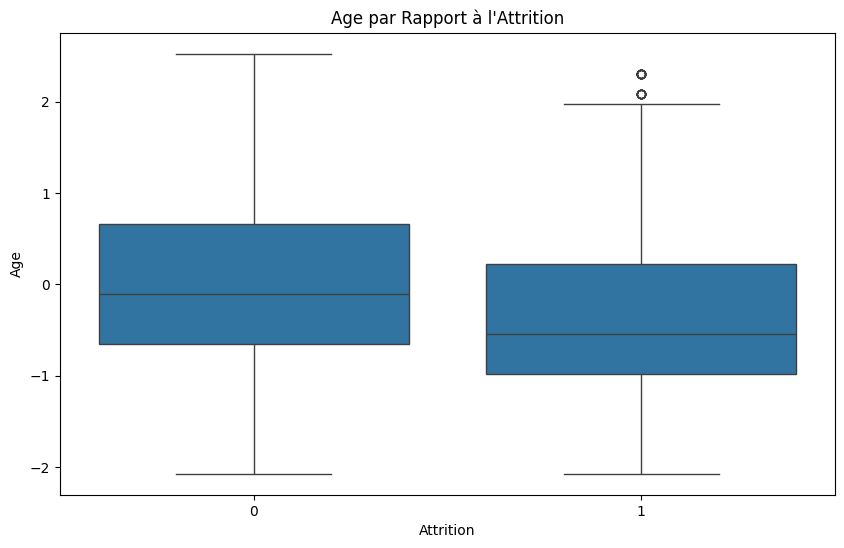

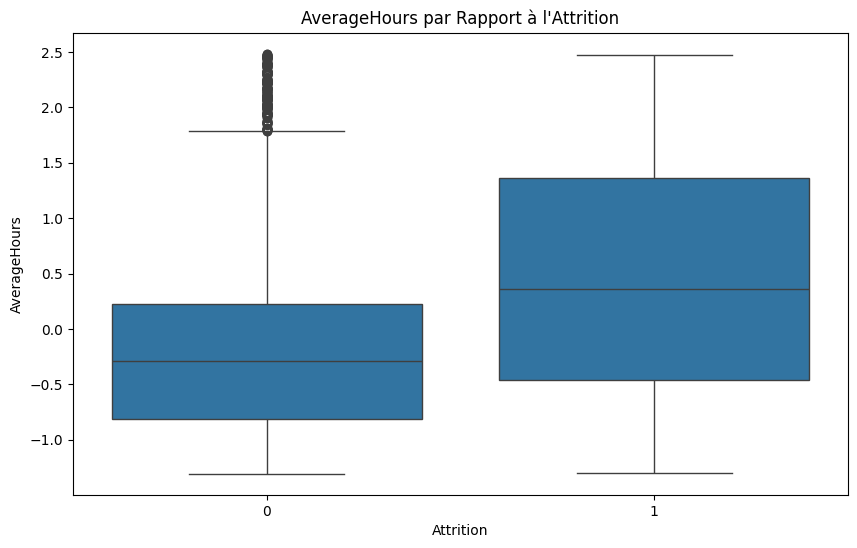

In [891]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='Age', data=data_prepared)
plt.title('Age par Rapport à l\'Attrition')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='AverageHours', data=data_prepared)
plt.title('AverageHours par Rapport à l\'Attrition')
plt.show()

Grace aux boites à moustache ci-dessus, on remarque que les employés plus agés ont tendance à rester dans l'entreprise et les employés faisant plus d'heures ont tendance à quitter l'entreprise.

### Modèles

Dans cette partie nous avons entraîner différents modèles de prédiction afin de sélectionner celui qui correspond le mieux à nos nos problèmes.

In [882]:
from sklearn.model_selection import train_test_split

X = data_prepared.drop("Attrition", axis=1)
y = data_prepared["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Les données d'entraînement et de test ont été répartis en 70/30 respectivement.

In [883]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Perceptron": Perceptron(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=1000, random_state=42)
}

# Entraînement et prédiction
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)


Nous entraînons 7 modèles :
- Perceptron
- LogisticRegression
- SVM
- KNN
- NaiveBayes
- DecisionTree
- RandomForest

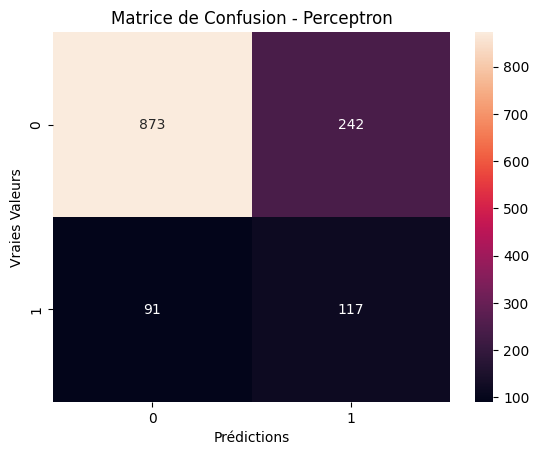

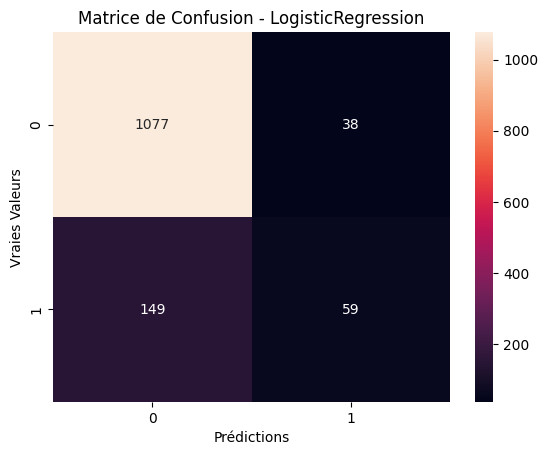

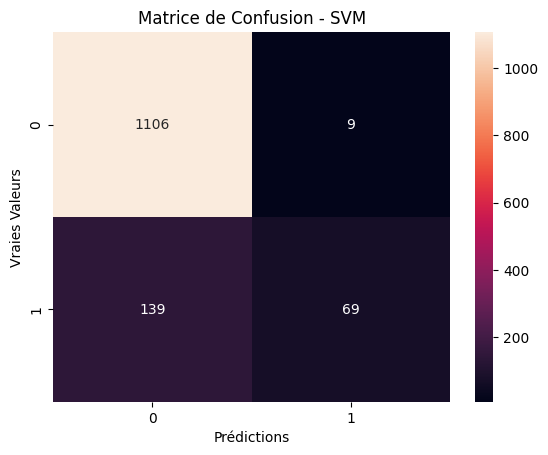

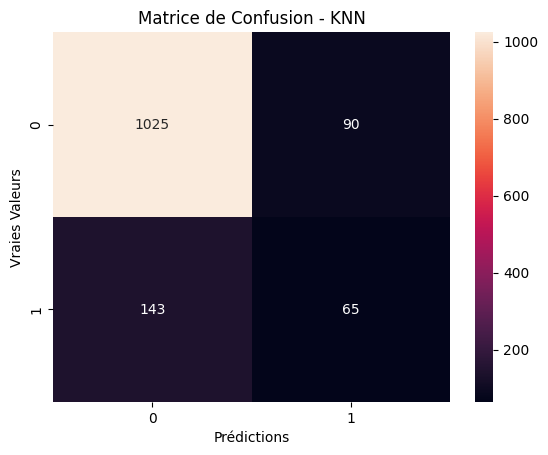

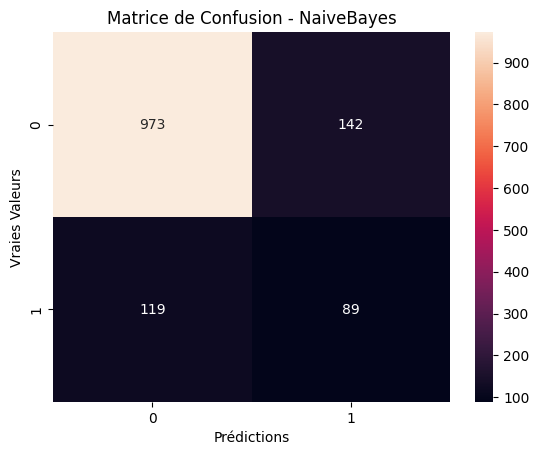

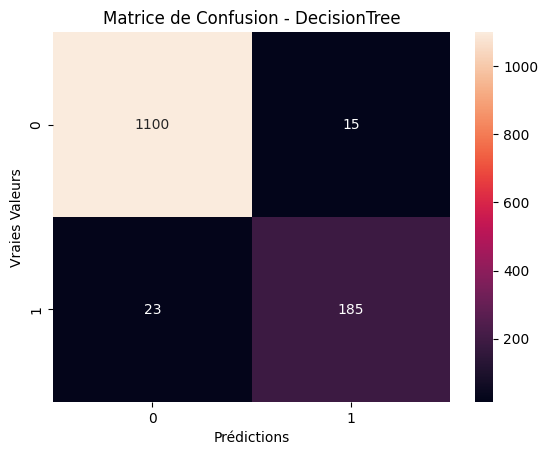

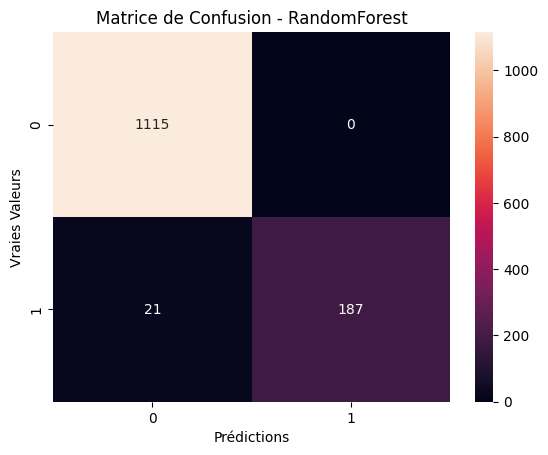

In [885]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, y_pred in predictions.items():
   cm = confusion_matrix(y_test, y_pred)
   plt.figure()
   sns.heatmap(cm, annot=True, fmt="d")
   plt.title(f"Matrice de Confusion - {name}")
   plt.xlabel("Prédictions")
   plt.ylabel("Vraies Valeurs")
   plt.show()


Nous commençons par faire une matrice de confusion pour chaque modèle.  

Les deux valeurs du bas signifient respectivement le total des faux négatifs (FN) et des vrais positifs (VP).  
Et les deux valeurs du haut signifient respectivement le total des vrais négatifs (VN) et des faux positifs (FP).  

On remarque par exemple que le Perceptron (le premier) à relativement peu de faux négatifs mais qu'il a, à l'inverse, beaucoup de faux positifs.  

Selon les matrices de confusions le meilleur modèle serait le RandomForest (le dernier) qui n'a aucun faux positif et très peu de faux négatifs.  

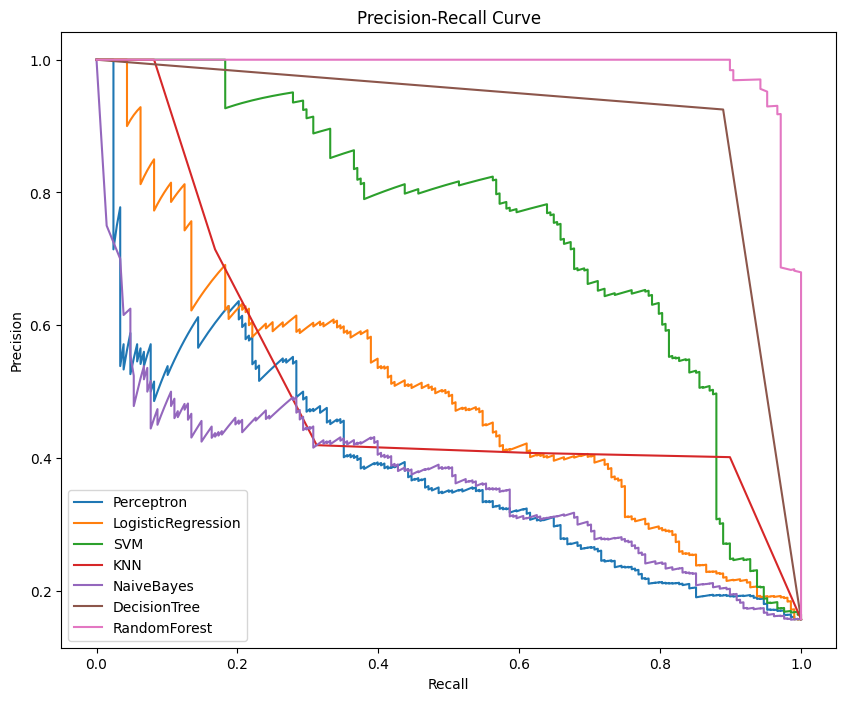

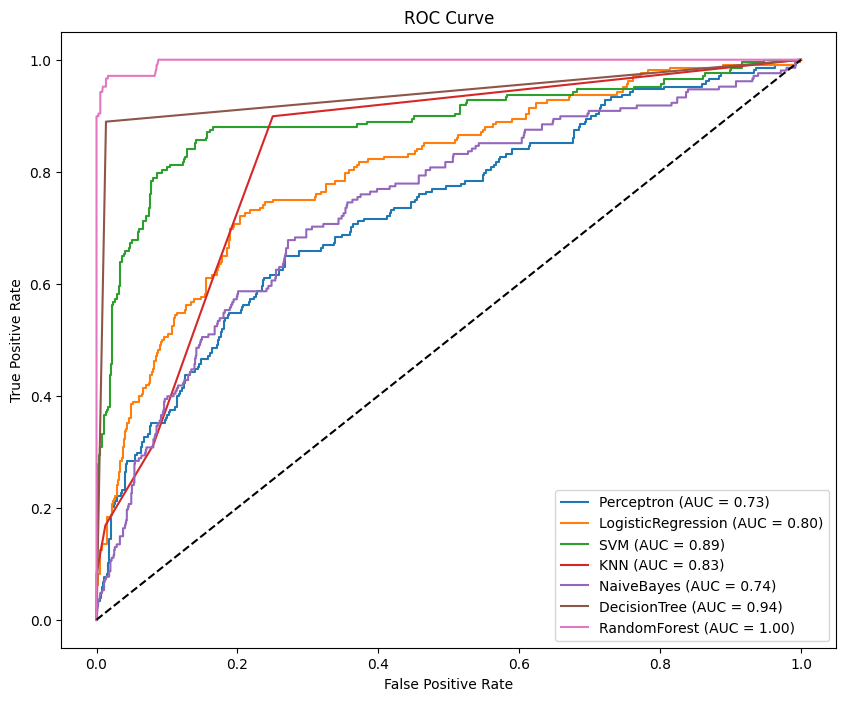

In [886]:
from sklearn.metrics import precision_recall_curve

# Tracer les courbes de Précision-Rappel
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(recall, precision, label=f"{name}")
    else:
        y_pred = model.decision_function(X_test)
        precision, recall, _ = precision_recall_curve(y_test, y_pred) 
        plt.plot(recall, precision, label=f"{name}")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    else:
        y_pred = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


Les deux courbes ci-dessus compares les performances des différents modèles.  

La première, Precision-Recall Curve, trace la précision (proportion de VP et de FP) contre le rappel (proportion de VP et de FN).  
La deuxième, ROC Curve, trace le taux de VP (le rappel) contre le taux de FP.  

Dans les deux cas, plus la courbe s'éloigne du centre du graphique, meilleur est le modèle.  
On voit donc que dans les 2 cas c'est la courbe du RandomForest qui est la meilleure.  

La case en bas à gauche du deuxième graphique donne l'AUC (Area Under Curve) de chaque modèle. Si l'AUC approche 1 le modèle est performant, et s'il approche 0.5 il ne fait pas mieux q'un choix aléatoire.  

Le meilleur AUC est celui du RandomForest, à 1 (arrondi de 0.997).

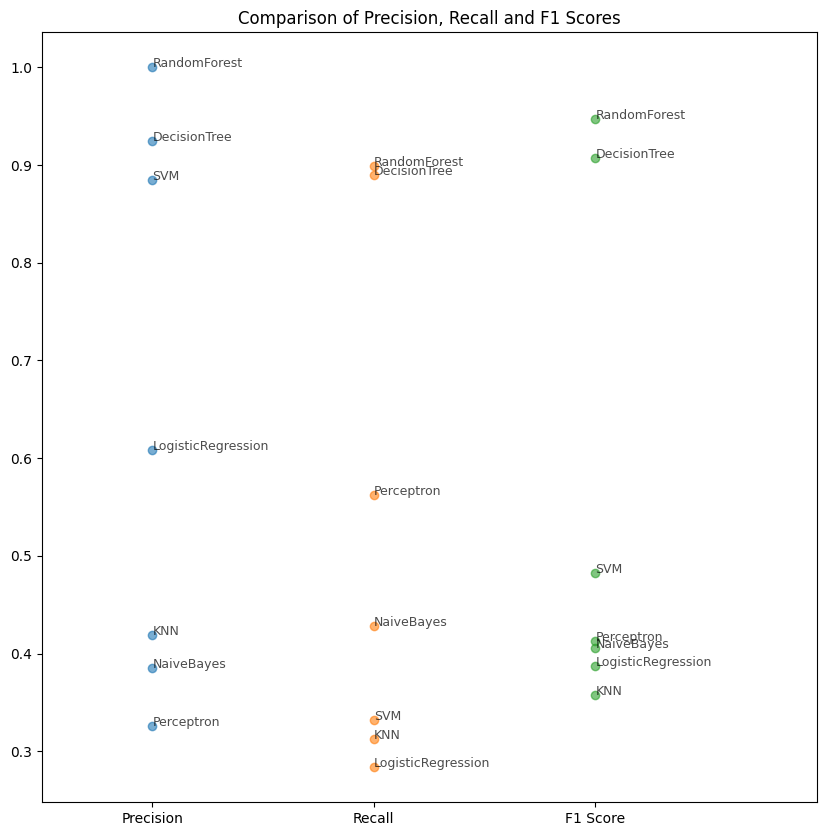

In [892]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_scores = []
recall_scores = []
f1_scores = []

for name, y_pred in predictions.items():
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred,))
    f1_scores.append(f1_score(y_test, y_pred,))
    
score_df = pd.DataFrame({
    'Model': models.keys(),
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

plt.figure(figsize=(10, 10))
for i, measure in enumerate(['Precision', 'Recall', 'F1 Score']):
    y = score_df[measure]
    x = np.random.normal(i + 1, 0.0, size=len(y))
    plt.scatter(x, y, alpha=0.6)
    for j, model in enumerate(score_df['Model']):
        plt.text(x[j], y[j], model, fontsize=9, alpha=0.7)
plt.xticks([1, 2, 3], ['Precision', 'Recall', 'F1 Score'])
plt.xlim(0.5, 4)
plt.title("Comparison of Precision, Recall and F1 Scores")
plt.show()


Le graphe ci-dessus montre les performance des différents modèles selon plusieurs métriques.  

Le F1 Score, que nous n'avons pas encore vu, fait une moyenne entre la précision et le rappel.

In [888]:
from sklearn.metrics import roc_auc_score

scores = []

for name, y_pred in predictions.items():
    y_proba = models[name].predict_proba(X_test)[:, 1] if hasattr(models[name], "predict_proba") else None
    auc_score = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    scores.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': auc_score
    })

scores_df = pd.DataFrame(scores)
print(scores_df)


                Model  Precision    Recall  F1 Score       AUC
0          Perceptron   0.325905  0.562500  0.412698       NaN
1  LogisticRegression   0.608247  0.283654  0.386885  0.802324
2                 SVM   0.884615  0.331731  0.482517  0.890734
3                 KNN   0.419355  0.312500  0.358127  0.832983
4          NaiveBayes   0.385281  0.427885  0.405467  0.739792
5        DecisionTree   0.925000  0.889423  0.906863  0.937985
6        RandomForest   1.000000  0.899038  0.946835  0.996971


Nous voyons ici un résumé des métriques de performances des différents modèles.  

Le RandomForest a de loin les meilleures perfomances parmis les 7 modèles.

In [893]:
import time

training_times = []
prediction_times = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    training_times.append(time.time() - start_time)

    start_time = time.time()
    model.predict(X_test)
    prediction_times.append(time.time() - start_time)
        
time_df = pd.DataFrame({
    'Model': models.keys(),
    'Training Time (s)': training_times,
    'Prediction Time (s)': prediction_times
})
print(time_df)


                Model  Training Time (s)  Prediction Time (s)
0          Perceptron           0.015633             0.003005
1  LogisticRegression           0.069603             0.002999
2                 SVM           0.670337             0.098163
3                 KNN           0.003001             0.082339
4          NaiveBayes           0.006723             0.002367
5        DecisionTree           0.026687             0.001999
6        RandomForest           3.389240             0.115155


On peut voir ci-dessus que malgrés le fait que le RandomForest soit plus performant, il prend plus de temps à s'entraîner et à prédire que les autres. Mais la différence se comptant en secondes ou centièmes de seconde pour notre data set, cela n'impactera pas notre choix.

### Résultats

Nous allons donc utiliser le RandomForest pour prédire l'attrition des employés de HumanForYou.

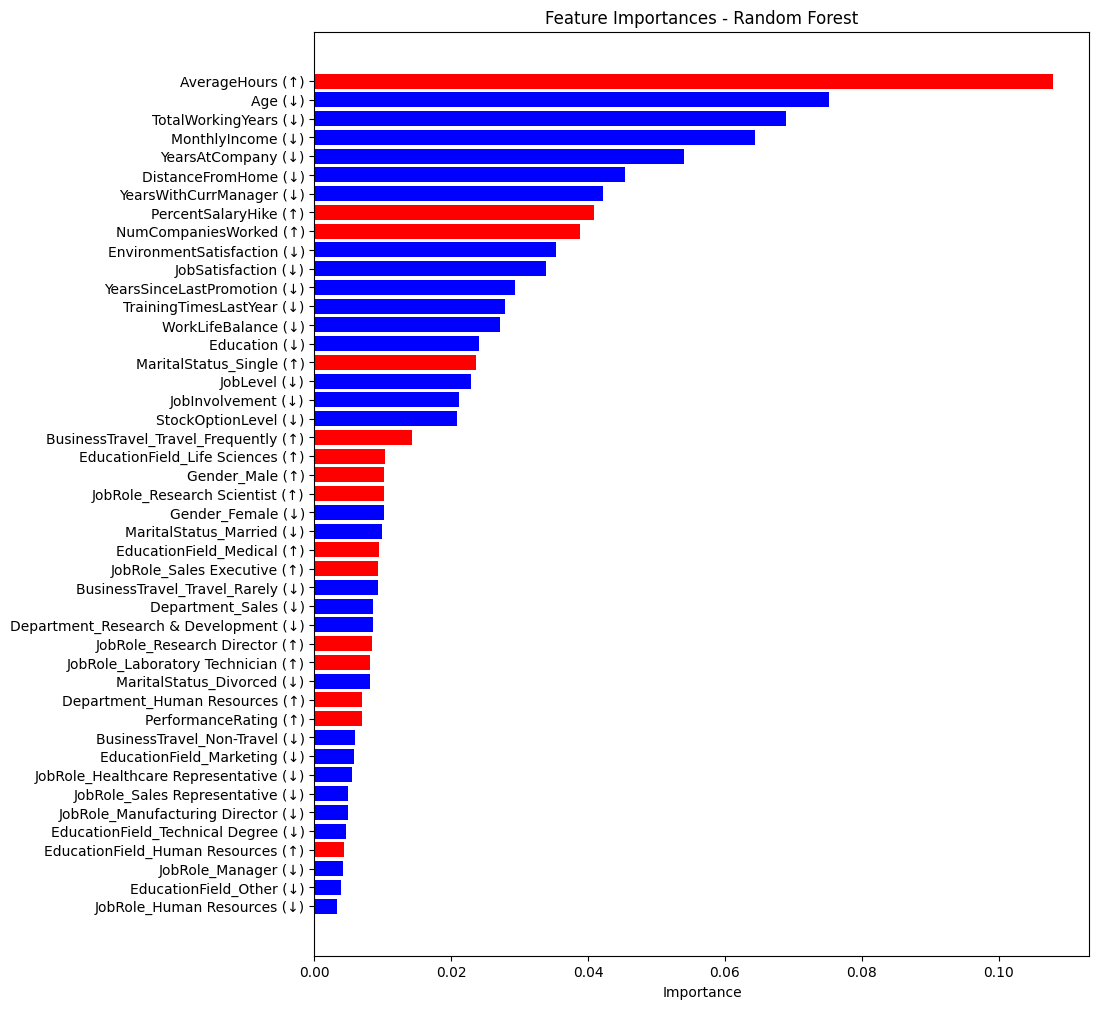

In [890]:
importances = models['RandomForest'].feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Calculer les coefficients de corrélation entre les caractéristiques et l'attrition
correlations = data_prepared.corr()['Attrition'].drop('Attrition')

# Ajouter les flèches pour indiquer le sens de la fluctuation
fluctuation_directions = ['↑' if corr > 0 else '↓' for corr in correlations.iloc[indices]]

# Afficher les importances des caractéristiques avec les directions de fluctuation
plt.figure(figsize=(10, 12))
plt.barh(range(len(importances)), importances[indices], align='center', color=['red' if corr > 0 else 'blue' for corr in correlations.iloc[indices]])
plt.yticks(range(len(importances)), [f"{X.columns[i]} ({fluctuation_directions[j]})" for j, i in enumerate(indices)])
plt.xlabel('Importance')
plt.title('Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.show()


Le graphique ci-dessus représente l'importance de chaque colonne dans la possibilité qu'un employé parte. Une colonne rouge indique qu'elle aura tendance à faire partir un employé et une colonne en bleu indique qu'elle aura tendance à le faire rester.  
Par exemple un employé ayant travaillé dans beaucoup d'entreprises aura tendance à partir et un employé ayant un bon équilibre travail/vie privé aura tendance à rester.  

On peut voir que les deux variables les plus importantes sont les heures moyennes faites et l'age de l'employé.  
Un employé faisant beaucoup d'heure va facilement quitter l'entreprise mais un employé agé va plus difficilement partir.

## Conclusion

En conclusion, nous avons développé un modèle de prédiction pour l'attrition des employés de l'entreprise HumanForYou. Après avoir traité et analysé les données, nous avons testé plusieurs modèles de machine learning.

Parmi ces modèles, le Random Forest s'est avérée être le plus performant, avec les meilleures métriques de précision, rappel, F1 Score et AUC.

Les analyses des importances des caractéristiques ont révélé que les heures moyennes travaillées dans une journée et l'âge des employés sont des facteurs déterminants dans la prédiction de l'attrition. Les employés plus âgés ont tendance à rester dans l'entreprise, tandis que ceux qui travaillent plus d'heures sont plus susceptibles de partir.

Un example de mesure à prendre pour réduire le taux de rotation serait d'essayer de réduire les heures supplémentaires faites par les employés travaillant beaucoup.